In [1]:
# how to import python files in other directory
import os
import sys
os.chdir("../../")
now_dir = os.getcwd()
print(now_dir)

# the path appended to sys.path is an absolute path
sys.path.append(os.path.join(now_dir, r'models\utils'))
sys.path.append(os.path.join(now_dir, r'models\aln'))
# sys.path.append(os.path.join(now_dir, r'models\thalamus'))
# sys.path.append(os.path.join(now_dir, r'models\demo_model'))

d:\mynew\demo_all


In [2]:

import pypet as pp 
import numpy as np 

# utils libs
import runModels as rm 
'''
parametrization_demo = pp.cartesian_product({
    'g_h': [float(round(elem, 3)) for elem in np.linspace(0.0, 0.08, 20)],
    'g_LK': [float(round(elem, 3)) for elem in np.linspace(0.0, 0.08, 20)],
    'model': ['thalamus']
}) # {'a': [...], 'b': [...], 'model': [...]}
parametrization_demo = pp.cartesian_product({
    'g_h': [round(elem, 3) for elem in [0.0, 0.01, 0.02]],
    'g_LK': [round(elem, 3) for elem in [0.0, 0.01, 0.02]],
    'model': ['thalamus']
})
type(parametrization_demo['g_h'][0]) # np.linspace will cause the type of number to be np.float64, which is conflicted with later computation?
'''

parametrization_demo = pp.cartesian_product({
    #'mue_ext_mean': [float(round(elem, 3)) for elem in np.linspace(0.0, 3.0, 251)],
    'mue_ext_mean': [float(round(elem, 3)) for elem in np.linspace(0.0, 3.0, 51)],
    #'mui_ext_mean': [float(round(elem, 3)) for elem in np.linspace(0.0, 3.0, 251)],
    'mui_ext_mean': [float(round(elem, 3)) for elem in np.linspace(0.0, 3.0, 51)],
    'model': ['aln']
}) # {'a': [...], 'b': [...], 'model': [...]}


In [3]:
import defaultParameters as dp
params = dp.loadDefaultParams(singleNode=1)
params['dt'] = 0.1
params['fast_interp'] = 1
params['global_delay'] = 1 # when it turns to 0, the program will get error?
params['distr_delay'] = 0

params['c_gl'] = 0.40

params['ext_exc_rate'] = 0.0
params['ext_exc_current'] = 0.0

params['a'] = 0.0
params['b'] = 15.0
params['tauA'] = 1000.0
params['mue_ext_mean'] = 2.8
params['mui_ext_mean'] = 2.0

'''
params['Jee_max'] = 2.43
params['Jii_max'] = -1.64
params['Jie_max'] = 2.60
params['Jei_max'] = -3.3

params['signalV'] = 20.0
params['mui_ext_mean'] = 1.40
params['mue_ext_mean'] = 1.35

params['sigma_ou'] = 0.046
params['Ke_gl'] = 252.0

params['de']  = 4.0
params['di']  = 2.0
'''
params['CmatFileName'] = ""
params['DmatFileName'] = ""
params 

{'dt': 0.1,
 'duration': 20000,
 'seed': 0,
 'model': 'aln',
 'load_point': 'none',
 'warn': 0,
 'dosc_version': 0,
 'distr_delay': 0,
 'filter_sigma': 0,
 'fast_interp': 1,
 'density': 1.0,
 'Cmat': array([[0.]]),
 'lengthMat': array([[0.]]),
 'global_delay': 1,
 'signalV': 7.5,
 'c_gl': 0.4,
 'Ke_gl': 250.0,
 'surfaceSC': 0.0,
 'interhem_strength': 0.0,
 'tau_ou': 5.0,
 'sigma_ou': 0.0,
 'mue_ext_mean': 2.8,
 'mui_ext_mean': 2.0,
 'ext_exc_rate': 0.0,
 'ext_inh_rate': 0.0,
 'ext_exc_current': 0.0,
 'ext_inh_current': 0.0,
 'sigmae_ext': 1.5,
 'sigmai_ext': 1.5,
 'A_sin': 0.0,
 'f_sin': 0.0,
 'ph_sin': 0.0,
 'Ke': 800.0,
 'Ki': 200.0,
 'de': 1.0,
 'di': 1.0,
 'tau_se': 2.0,
 'tau_si': 5.0,
 'tau_de': 1.0,
 'tau_di': 1.0,
 'cee': 0.3,
 'cie': 0.3,
 'cei': 0.5,
 'cii': 0.5,
 'Jee_max': 2.43,
 'Jie_max': 2.6,
 'Jei_max': -3.3,
 'Jii_max': -1.64,
 'a': 0.0,
 'b': 15.0,
 'EA': -80.0,
 'tauA': 1000.0,
 'C': 200.0,
 'gL': 10.0,
 'EL': -65.0,
 'DeltaT': 1.5,
 'VT': -50.0,
 'Vr': -70.0,
 'Vs':

In [4]:
# for test
'''
npar = 2
for k in parametrization_demo:
    params[k] = parametrization_demo[k][npar]
'''

t, rates_exc, rates_inh, mufe, mufi = rm.runModels(manual_params=params)
print(t.shape)
print(rates_exc.shape)
print(rates_inh.shape)

(200000,)
(1, 200000)
(1, 200000)


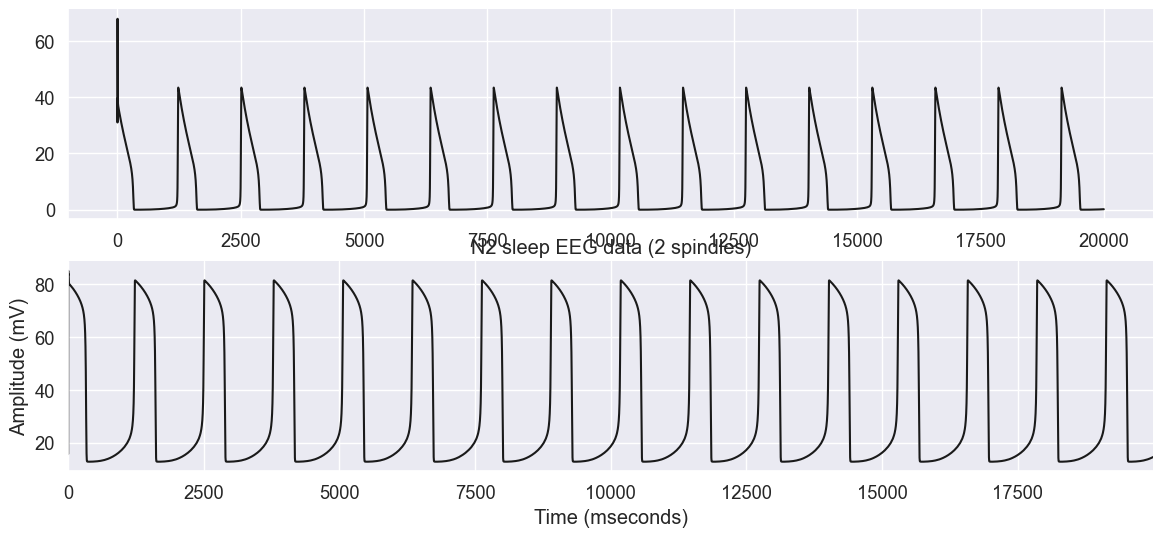

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.2)

fig, ax = plt.subplots(2, 1, figsize=(14, 6))
#plt.plot(t[:1000], V_t[:1000], lw=1.5, color='k')
plt.subplot(2,1,1)
plt.plot(t, rates_exc[0]*1000, lw=1.5, color='k')
plt.subplot(2,1,2)
plt.plot(t, rates_inh[0]*1000, lw=1.5, color='k')
plt.xlabel('Time (mseconds)')
plt.ylabel('Amplitude (mV)')
#
plt.xlim([t.min(), t.max()])
#plt.xlim([t[:1000].min(), t[:1000].max()])
plt.title('N2 sleep EEG data (2 spindles)')
sns.despine()

In [6]:
# run simulations
trajectoryName = 'results'
HDF_DIR = '.\data\hdf'
trajectoryFileName = os.path.join(HDF_DIR, 'aln_demo_21x21.hdf') 

import multiprocessing
ncores = multiprocessing.cpu_count()
print(f"number of cores: {ncores}")

env = pp.Environment(trajectory=trajectoryName, filename=trajectoryFileName,
                     add_time=True,
                     multiproc=True,
                     ncores=ncores,
                     wrap_mode="QUEUE",
                     log_stdout=False,
                     log_config=None
                     )

number of cores: 28


In [7]:
traj = env.v_trajectory

import pypet_parameter as pe
pe.add_parameters_all(traj, params)
traj.f_explore(parametrization_demo)
env.f_run(rm.runModels)
env.f_disable_logging()
print("Done.")

KeyboardInterrupt: 

In [ ]:
traj.f_load(filename=trajectoryFileName)
traj.v_auto_load = True 

In [ ]:

traj.f_get_run_names()
dt = traj.f_get_parameters()['parameters.dt'].f_get()
print(dt)
a = traj.f_get_explored_parameters()['parameters.mue_ext_mean'].f_get_range()
print(a)
b = traj.f_get_explored_parameters()['parameters.mui_ext_mean'].f_get_range()
print(b)



In [ ]:
traj.results.aln_results[0].rates_exc[0]

In [ ]:
traj.f_get_explored_parameters().keys()

In [ ]:
import pandas as pd
nResults = len(traj.f_get_run_names())
dt = traj.f_get_parameters()['parameters.dt'].f_get()
exploredParameters = traj.f_get_explored_parameters()

niceParKeys = [p.split('.')[-1] for p in exploredParameters.keys()]

dfResults = pd.DataFrame(columns=niceParKeys, dtype=object)

for nicep, p in zip(niceParKeys, exploredParameters.keys()):
    dfResults[nicep] = exploredParameters[p].f_get_range()

In [ ]:
from joblib import Parallel, delayed 
import multiprocessing 
num_cores = multiprocessing.cpu_count()
plot_results = []

for rInd in range(len(dfResults)):
    max_rate = np.max(traj.results.aln_results[rInd].rates_exc[0]*1000)
    dfResults.loc[rInd, "max_rate"] = max_rate 
    plot_results.append(max_rate)

In [ ]:

import matplotlib.pyplot as plt

mues = np.unique(dfResults['mue_ext_mean'])
muis = np.unique(dfResults['mui_ext_mean'])
plot_results_matrix = np.reshape(plot_results, (len(mues), len(muis))).T

plt.figure(figsize=(10,8), dpi=300)
plt.imshow(plot_results_matrix, origin='lower', aspect='auto', extent=[mues[0], mues[-1], muis[0], muis[-1]])

plt.xlabel("Input to E", fontsize=30)
plt.ylabel("Input to I", fontsize=30)
plt.clim(0, 80)
cbar = plt.colorbar(label="Maximum rate of E(Hz)", extend='max')
plt.show()